Simulate and evaluate different queueing architectures.
Algorithms Implemented:-
- FIFO(with HoL Blocking)
- VOQ(Optimal Matching)
- iSLIP Scheduling

In [ ]:
from collections import deque
import itertools 
import matplotlib.pyplot as plt
import numpy as np

Input Data.

In [ ]:
# (packet_id, arrival_time, source_input, destination_output)
INPUT_TRACE = [
    ("p1",  0, 0, 0),
    ("p2",  0, 0, 1),
    ("p3",  0, 1, 0),
    ("p4",  0, 1, 2),
    ("p5",  0, 2, 0),
    ("p6",  1, 0, 2),
    ("p7",  1, 2, 1),
    ("p8",  2, 1, 1),
    ("p9",  2, 2, 2),
    ("p10", 3, 0, 1),
    ("p11", 3, 1, 0),
    ("p12", 3, 2, 1),
    ("p13", 4, 0, 0),
    ("p14", 4, 1, 2),
    ("p15", 4, 2, 2),
    ("p16", 5, 0, 2),
    ("p17", 5, 1, 1),
    ("p18", 5, 2, 0),
]

N = 3

FIFO(with HoL Blocking)

In [ ]:
def simulate_fifo():
    queues = [deque() for _ in range(N)]
    arrivals = {}

    for p in INPUT_TRACE:
        arrivals.setdefault(p[1], []).append(p)

    t = 0
    backlog = {}

    while True:
        if t in arrivals:
            for p in arrivals[t]:
                queues[p[2]].append(p)

        backlog[t] = sum(len(q) for q in queues)

        if backlog[t] == 0:
            break

        output_busy = [False] * N

        for i in range(N):
            if queues[i]:
                pkt = queues[i][0]
                if not output_busy[pkt[3]]:
                    output_busy[pkt[3]] = True
                    queues[i].popleft()

        t += 1

    return t, backlog

fifo_time, fifo_backlog = simulate_fifo()
print("FIFO Time:", fifo_time)

FIFO Time: 11


VOQ Optimal Function

In [ ]:
def all_matchings(edges):
    res = []
    for r in range(len(edges) + 1):
        for comb in itertools.combinations(edges, r):
            used_i, used_j = set(), set()
            ok = True

            for i, j in comb:
                if i in used_i or j in used_j:
                    ok = False
                    break
                used_i.add(i)
                used_j.add(j)

            if ok:
                res.append(comb)

    return res


def simulate_voq_optimal():
    voq = [[deque() for _ in range(N)] for _ in range(N)]
    arrivals = {}

    for p in INPUT_TRACE:
        arrivals.setdefault(p[1], []).append(p)

    t = 0
    backlog = {}

    def total():
        return sum(len(voq[i][j]) for i in range(N) for j in range(N))

    while True:
        if t in arrivals:
            for p in arrivals[t]:
                voq[p[2]][p[3]].append(p)

        backlog[t] = total()

        if backlog[t] == 0:
            break

        edges = [(i, j) for i in range(N) for j in range(N) if voq[i][j]]
        best = max(all_matchings(edges), key=len, default=[])

        for i, j in best:
            voq[i][j].popleft()

        t += 1

    return t, backlog


voq_time, voq_backlog = simulate_voq_optimal()
print("VOQ Optimal Time:", voq_time)

VOQ Optimal Time: 7


iSLIP Function

In [ ]:
def simulate_islip():
    voq = [[deque() for _ in range(N)] for _ in range(N)]
    arrivals = {}

    for p in INPUT_TRACE:
        arrivals.setdefault(p[1], []).append(p)

    grant_ptr = [0] * N
    accept_ptr = [0] * N

    t = 0
    backlog = {}

    def total():
        return sum(len(voq[i][j]) for i in range(N) for j in range(N))

    while True:
        # arrivals
        if t in arrivals:
            for p in arrivals[t]:
                voq[p[2]][p[3]].append(p)

        backlog[t] = total()

        if backlog[t] == 0:
            break

        # REQUEST
        requests = {j: [] for j in range(N)}
        for i in range(N):
            for j in range(N):
                if voq[i][j]:
                    requests[j].append(i)

        # GRANT
        grants = {}
        for j in range(N):
            if not requests[j]:
                continue

            for k in range(N):
                i = (grant_ptr[j] + k) % N
                if i in requests[j]:
                    grants[i] = j
                    break

        # ACCEPT (IMPORTANT FIX)
        accepted = {}

        for i, j in grants.items():
            if i not in accepted:
                accepted[i] = j

        # SEND + POINTER UPDATE
        for i, j in accepted.items():
            if voq[i][j]:
                voq[i][j].popleft()
                grant_ptr[j] = (i + 1) % N
                accept_ptr[i] = (j + 1) % N

        t += 1

    return t, backlog


islip_time, islip_backlog = simulate_islip()
print("iSLIP Time:", islip_time)

iSLIP Time: 8


Total Service time comparision.

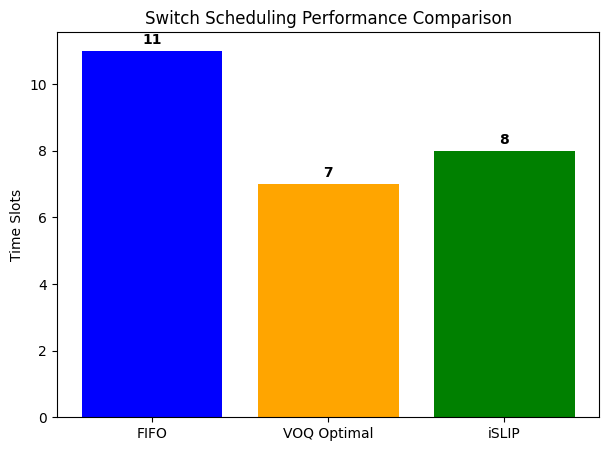

In [ ]:
algos = ["FIFO", "VOQ Optimal", "iSLIP"]
times = [fifo_time, voq_time, islip_time]

colors = ["blue", "orange", "green"]

plt.figure(figsize=(7,5))
bars = plt.bar(algos, times, color=colors)

plt.title("Switch Scheduling Performance Comparison")
plt.ylabel("Time Slots")

for i, v in enumerate(times):
    plt.text(i, v + 0.2, str(v), ha='center', fontweight='bold')

plt.show()

Visualization

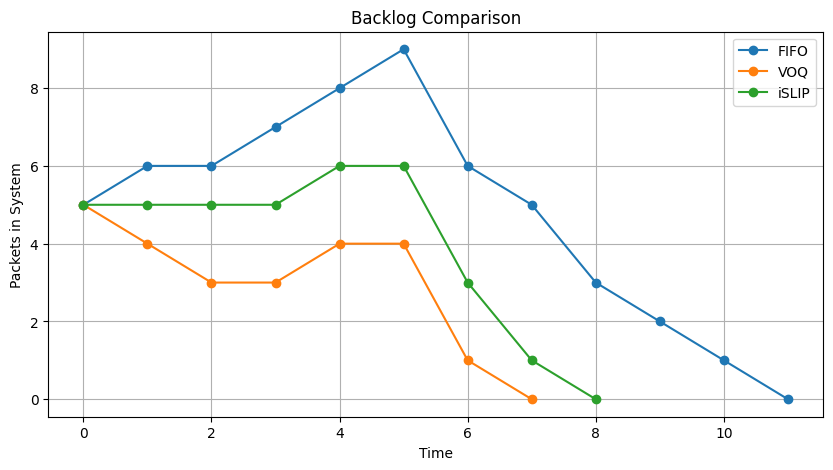

: 

In [ ]:
plt.figure(figsize=(10,5))

def plot_backlog(backlog, label):
    t = list(backlog.keys())
    v = list(backlog.values())
    plt.plot(t, v, marker='o', label=label)

plot_backlog(fifo_backlog, "FIFO")
plot_backlog(voq_backlog, "VOQ")
plot_backlog(islip_backlog, "iSLIP")

plt.xlabel("Time")
plt.ylabel("Packets in System")
plt.title("Backlog Comparison")
plt.legend()
plt.grid()
plt.show()